## CSI 500 - Review Python

In [1]:
import math
import numpy as np  
import matplotlib.pyplot as plt
np.random.seed(2019)

### 1. Iteration

In [2]:
nums = [1,2,3,4,5]
for n in nums:
    if n == 4:
        break

In [3]:
nums = [10, 20, 30, 40, 50, 60]
sum = 0
for k in nums:
    sum = sum + k

In [4]:
for k in range(len(nums)):
    sum = sum + nums[k]

In [5]:
# another way to create a list using iterator
my_nums = [i*0.5 for i in range(10)]

#### Quiz 1: What is wrong with the following code fragment? Modify it.

In [6]:
a = []
for i in range (10) :
    a.append(i * i)

In [7]:
a

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]

#### Quiz 2: Use iterations to print the diamond below:
#### &nbsp;&nbsp;&nbsp;&nbsp;*
#### &nbsp;&nbsp;&nbsp;***
#### &nbsp;&nbsp;*****
#### &nbsp;*******
#### *********
#### &nbsp;*******
#### &nbsp;&nbsp;*****
#### &nbsp;&nbsp;&nbsp;***
#### &nbsp;&nbsp;&nbsp;&nbsp;*

In [8]:
for i in range(5):
    print(' ' * (4-i) + '*' * (2*i+1))

for i in range(3, -1, -1):
    print(' ' * (4-i) + '*' * (2*i+1))

    *
   ***
  *****
 *******
*********
 *******
  *****
   ***
    *


#### Quiz 3: Fibonacci sequence
In Fibonacci sequence, each number is the sum of the two previous numbers, where the first two numbers are 0 and 1. Write a function 'fib' that prints the Fibonacci series based on F's index. (e.g., fib(4) will print 0, 1, 1, 2, 3)

In [9]:
def fib(x):
    a = [0, 1]
    if x == 0:
        return [0]
    for i in range(x-1):
        a.append(a[-1] + a[-2])
    return a

In [10]:
fib(4)

[0, 1, 1, 2, 3]

## Randomness

#### randi

In [11]:
print(np.random.randint(1,7))
print(np.random.randint(1,7,size=2))
print(np.random.randint(1,7,size=(3,5)))

1
[3 6]
[[1 1 6 5 3]
 [1 1 1 6 4]
 [5 1 3 6 1]]


#### Quiz 4: Simulate coin flipping

In [12]:
print(np.random.choice(['Heads','Tails']))

Heads


In [13]:
?np.random

#### rand

In [14]:
print(np.random.random())
print(np.random.random(5))
print(np.random.random((2,3)))

0.8892146954077474
[0.14847623 0.98472349 0.03236122 0.51535075 0.20112905]
[[0.88601087 0.51361992 0.57830159]
 [0.29928265 0.8371974  0.52664983]]


In [15]:
np.random.choice(["A","B","C","D"],size =1,replace=False)

array(['D'], dtype='<U1')

In [16]:
presentation = ["Jungwon","Sukmin","Colin","Ryan","Hannah","Enoch"]
np.random.permutation(presentation)
#random order

array(['Hannah', 'Ryan', 'Jungwon', 'Sukmin', 'Colin', 'Enoch'],
      dtype='<U7')

In [17]:
?np.random.permutation

#### Quiz 5: Birthday

Assume that a year is 365 days, and the probability of being born on any of these 365 days is identical (i.e., uniform). In a class of 20 students, what is the probability that at least two students are born the same day? Use Monte Carlo Simulation to solve this problem.

In [18]:
# One way: compare each birthday with the birthdays after it
count = 0
for trial in range(10000):
    birthdays = np.random.randint(1, 366, 20)
    for i in range(19):
        if birthdays[i] in birthdays[i+1:]:
            count += 1
            break
count / 10000

0.4111

In [19]:
# Simpler way: use a set to remove duplicate birthdays
np.random.seed(2019)
count = 0
for trial in range(10000):
    birthdays = set(np.random.randint(1, 366, 20))
    if len(birthdays) != 20:
        count += 1

count / 10000

0.4115

### Teaching note for Quiz 5

The key idea is that a Python `set` keeps only unique values. If 20 random birthdays become a set with fewer than 20 values, then at least one birthday occurred more than once. Repeating this experiment 10,000 times and dividing the number of matches by 10,000 gives a Monte Carlo estimate of the probability.

In [20]:
?np.random.uniform

#### Quiz 6: Estimating pi
your code to throw data the the square randomly for 10,000 times. Compare the value with math.pi


In [21]:
def PIbyDarts(NumDarts, DM = 2):
    vecs = 2*np.random.ranf((NumDarts,DM))-1
    dists = np.sqrt((vecs**2).sum(1))
    NdartsIn = (dists < 1).sum()
    answer = 4.0 * NdartsIn / NumDarts
    return answer

In [22]:
PIbyDarts(10000)

np.float64(3.0976)

In [23]:
l = []
for i in range(1,21):
    k = 2**i
    l.append(float(PIbyDarts(k)))
l

[2.0,
 4.0,
 2.5,
 3.25,
 3.25,
 3.125,
 3.0625,
 3.0,
 3.2265625,
 3.109375,
 3.11328125,
 3.1259765625,
 3.17333984375,
 3.117919921875,
 3.152099609375,
 3.1346435546875,
 3.1488037109375,
 3.1426239013671875,
 3.1378555297851562,
 3.140045166015625]

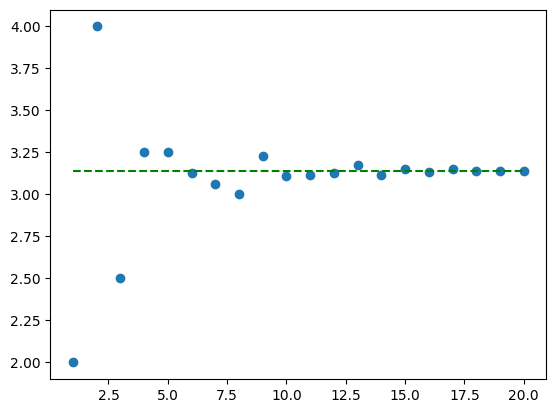

In [24]:
rng = [i for i in range(1,21)]
plt.scatter(rng,l)
plt.plot(rng,[np.pi]*len(rng),'--',color = 'green')

#### Quiz 8: stochastic models

From our lecture slide, compose codes for comparing deterministic and stochastic models.

(1) Create deterministic harvesting models where the amount of wheat follows the function:

$$N_{t+1} = N_{t} + rN_{t}\left ( 1-\frac{N_{t}}{K} \right ) - H$$

where $N_t$ is harvest at time t <br>
$r$ is population growth which is 0.15,<br>
$K$ is carrying capacity which is 1,000 <br>
$N_0$, the initial harvest at $t=0$, is 1000. <br><br>

Plot $N$ for $t = (0, 500)$ when $H = 25.0, 37.5, 40.0$. Specify labels for axis and insert a legend for three lines.

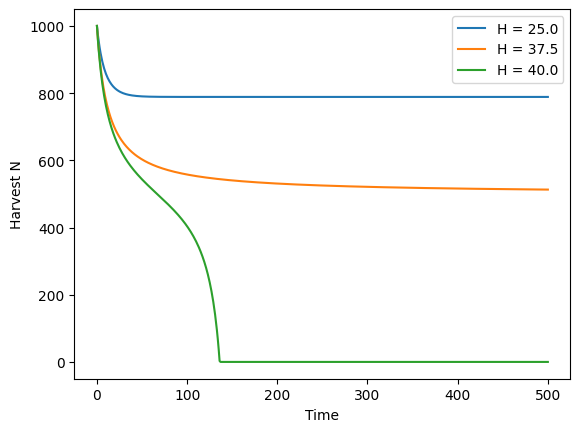

In [25]:
r = 0.15
K = 1000
H_values = [25.0, 37.5, 40.0]
times = np.arange(501)

for H in H_values:
    N = np.zeros(501)
    N[0] = 1000
    for t in range(500):
        N[t+1] = N[t] + r * N[t] * (1 - N[t] / K) - H
        N[t+1] = max(N[t+1], 0)
    plt.plot(times, N, label=f'H = {H}')

plt.xlabel('Time')
plt.ylabel('Harvest N')
plt.legend()
plt.show()

(2) Create a stochastic model for the same function. Here, $K = 1000$ and $H = 25$. Assume $r$ follows a normal distribution with mean of 0.15 and standard deviation of 0.05. Conduct a Monte Carlo simulation with 1,000 trials and create two plots: (1) showing the temporal change of the harvest between $t=0$ and $t=500$ and (2) a histogram of the harvest at $t = 500$.

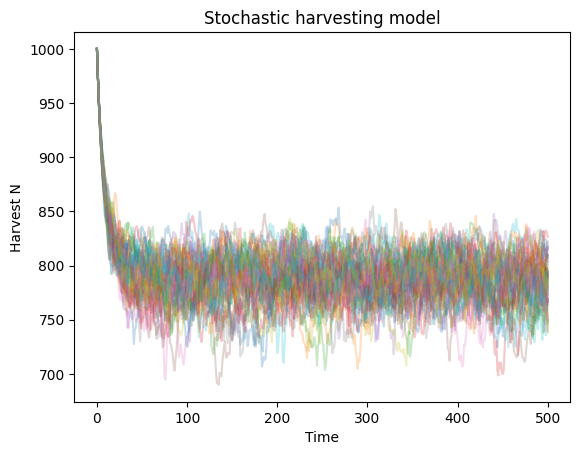

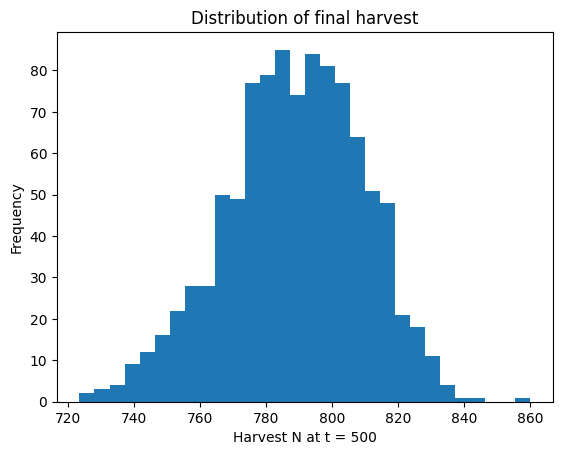

In [26]:
K = 1000
H = 25
num_trials = 1000
num_steps = 500
all_paths = np.zeros((num_trials, num_steps + 1))
all_paths[:, 0] = 1000

for trial in range(num_trials):
    for t in range(num_steps):
        r = np.random.normal(0.15, 0.05)
        N = all_paths[trial, t]
        next_N = N + r * N * (1 - N / K) - H
        all_paths[trial, t + 1] = max(next_N, 0)

# Plot a sample of temporal trajectories so the figure stays readable.
for trial in range(50):
    plt.plot(range(num_steps + 1), all_paths[trial], alpha=0.25)
plt.xlabel('Time')
plt.ylabel('Harvest N')
plt.title('Stochastic harvesting model')
plt.show()

# Histogram of harvest at t = 500 across all 1,000 trials.
plt.hist(all_paths[:, -1], bins=30)
plt.xlabel('Harvest N at t = 500')
plt.ylabel('Frequency')
plt.title('Distribution of final harvest')
plt.show()